In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Data/QVI_data.csv')
data['DATE'] = pd.to_datetime(data['DATE'])

display(data.head())

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [3]:
data['YEARMONTH'] = data['DATE'].dt.strftime('%Y%m').astype(int)

monthly_metrics = data.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    totSales=('TOT_SALES', 'sum'),
    nCustomers=('LYLTY_CARD_NBR', 'nunique'),
    nTxns=('TXN_ID', 'count')
).reset_index()

monthly_metrics['avgTxnPerCust'] = monthly_metrics['nTxns'] / monthly_metrics['nCustomers']

store_counts = monthly_metrics.groupby('STORE_NBR').size()
full_year_stores = store_counts[store_counts == 12].index
monthly_metrics = monthly_metrics[monthly_metrics['STORE_NBR'].isin(full_year_stores)]

print(f"Number of stores with full 12 months data: {len(full_year_stores)}")
display(monthly_metrics.head())

Number of stores with full 12 months data: 260


,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxns,avgTxnPerCust
0,1,201807,206.9,49,52,1.061224
1,1,201808,176.1,42,43,1.023810
2,1,201809,278.8,59,62,1.050847
3,1,201810,188.1,44,45,1.022727
4,1,201811,192.6,46,47,1.021739


In [4]:
import numpy as np

preTrialMeasures = monthly_metrics[monthly_metrics['YEARMONTH'] < 201902]

def calculate_similarity(target_store, metric_col):
    target_data = preTrialMeasures[preTrialMeasures['STORE_NBR'] == target_store][metric_col].values
    
    similarities = []
    for store in preTrialMeasures['STORE_NBR'].unique():
        if store == target_store: continue
        
        store_data = preTrialMeasures[preTrialMeasures['STORE_NBR'] == store][metric_col].values
        
        corr = np.corrcoef(target_data, store_data)[0, 1]
        
        dist = np.mean(np.abs(target_data - store_data))
        mag_dist = 1 - (dist - 0) / (preTrialMeasures[metric_col].max() - 0)
        
        similarities.append({'Store': store, 'Correlation': corr, 'Magnitude': mag_dist})
    
    return pd.DataFrame(similarities)

score_77 = calculate_similarity(77, 'totSales')
score_77['FinalScore'] = (score_77['Correlation'] + score_77['Magnitude']) / 2

print("Top potential control stores for Store 77:")
display(score_77.sort_values('FinalScore', ascending=False).head(5))

Top potential control stores for Store 77:


,Store,Correlation,Magnitude,FinalScore
220,233,0.903774,0.988655,0.946214
38,41,0.783232,0.972678,0.877955
15,17,0.842668,0.906234,0.874451
46,50,0.763866,0.979083,0.871474
107,115,0.689159,0.947182,0.818170


In [5]:
score_86 = calculate_similarity(86, 'totSales')
score_86['FinalScore'] = (score_86['Correlation'] + score_86['Magnitude']) / 2
control_86 = score_86.sort_values('FinalScore', ascending=False).iloc[0]['Store']

score_88 = calculate_similarity(88, 'totSales')
score_88['FinalScore'] = (score_88['Correlation'] + score_88['Magnitude']) / 2
control_88 = score_88.sort_values('FinalScore', ascending=False).iloc[0]['Store']

print(f"Final Selection:")
print(f"Trial Store 77 -> Control Store: 233")
print(f"Trial Store 86 -> Control Store: {int(control_86)}")
print(f"Trial Store 88 -> Control Store: {int(control_88)}")

Final Selection:
Trial Store 77 -> Control Store: 233
Trial Store 86 -> Control Store: 155
Trial Store 88 -> Control Store: 125


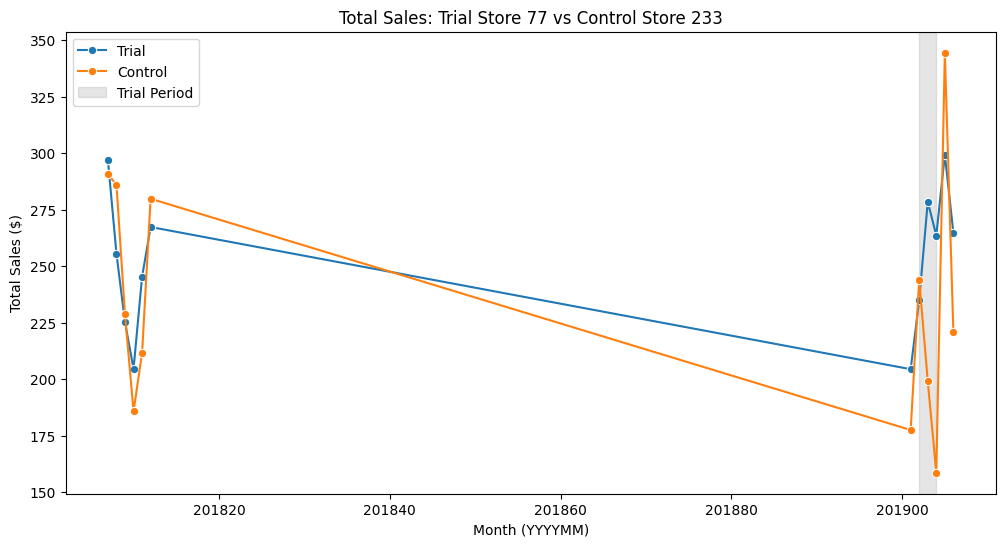

In [6]:
trial_store = 77
control_store = 233

compare_sales = monthly_metrics[monthly_metrics['STORE_NBR'].isin([trial_store, control_store])].copy()
compare_sales['Store_Type'] = compare_sales['STORE_NBR'].apply(lambda x: 'Trial' if x == trial_store else 'Control')

plt.figure(figsize=(12, 6))
sns.lineplot(data=compare_sales, x='YEARMONTH', y='totSales', hue='Store_Type', marker='o')
plt.axvspan(201902, 201904, color='gray', alpha=0.2, label='Trial Period')

plt.title(f'Total Sales: Trial Store {trial_store} vs Control Store {control_store}')
plt.xlabel('Month (YYYYMM)')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.show()

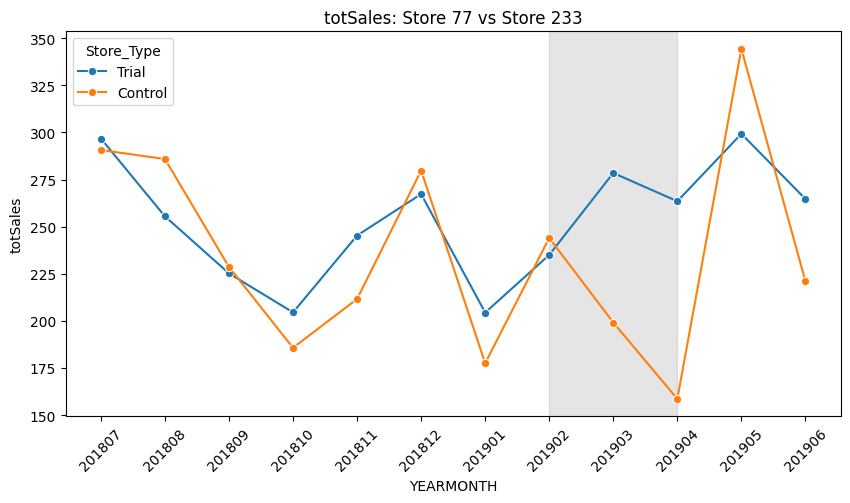

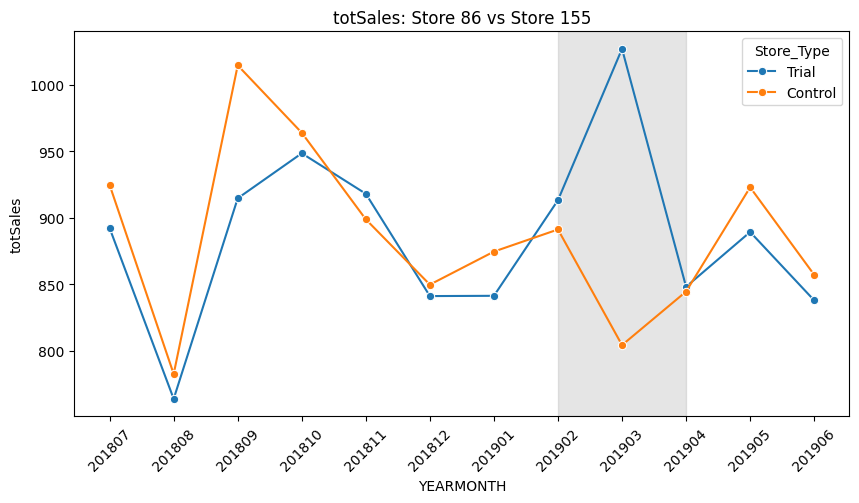

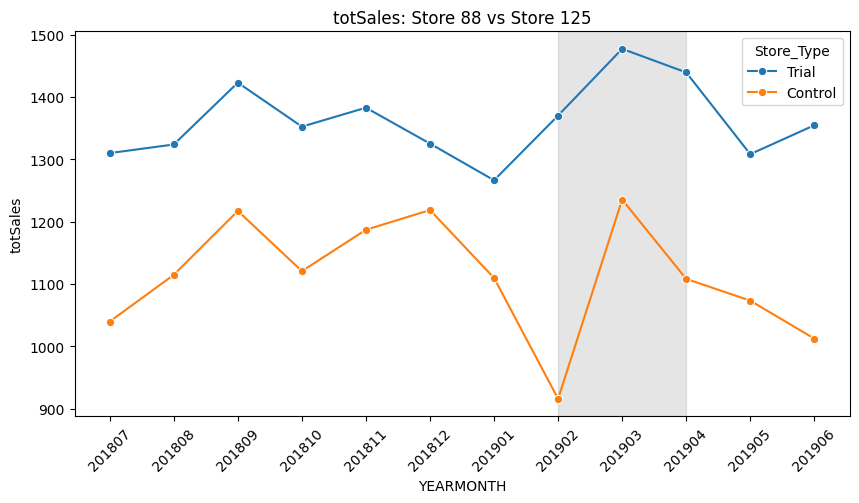

In [7]:
def plot_trial_assessment(trial_store, control_store, metric):
    compare_data = monthly_metrics[monthly_metrics['STORE_NBR'].isin([trial_store, control_store])].copy()
    compare_data['Store_Type'] = compare_data['STORE_NBR'].apply(lambda x: 'Trial' if x == trial_store else 'Control')
    compare_data['YEARMONTH'] = compare_data['YEARMONTH'].astype(str)
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=compare_data, x='YEARMONTH', y=metric, hue='Store_Type', marker='o')
    plt.axvspan('201902', '201904', color='gray', alpha=0.2, label='Trial Period')
    plt.title(f'{metric}: Store {trial_store} vs Store {control_store}')
    plt.xticks(rotation=45)
    plt.show()

trials = {77: 233, 86: 155, 88: 125}
for trial, control in trials.items():
    plot_trial_assessment(trial, control, 'totSales')

In [8]:
def calculate_trial_assessment(trial_store, control_store):
    pre_trial = monthly_metrics[(monthly_metrics['YEARMONTH'] < 201902) & 
                                (monthly_metrics['STORE_NBR'].isin([trial_store, control_store]))]
    
    trial_sales = pre_trial[pre_trial['STORE_NBR'] == trial_store]['totSales'].sum()
    control_sales = pre_trial[pre_trial['STORE_NBR'] == control_store]['totSales'].sum()
    scaling_factor = trial_sales / control_sales
    
    trial_period = monthly_metrics[(monthly_metrics['YEARMONTH'] >= 201902) & 
                                   (monthly_metrics['YEARMONTH'] <= 201904)]
    
    trial_actual = trial_period[trial_period['STORE_NBR'] == trial_store].set_index('YEARMONTH')['totSales']
    control_actual = trial_period[trial_period['STORE_NBR'] == control_store].set_index('YEARMONTH')['totSales']
    
    expected_sales = control_actual * scaling_factor
    
    percentage_diff = (trial_actual - expected_sales) / expected_sales
    return percentage_diff

for trial, control in trials.items():
    print(f"\n--- Assessment for Trial Store {trial} ---")
    diff = calculate_trial_assessment(trial, control)
    print(diff)


--- Assessment for Trial Store 77 ---
YEARMONTH
201902   -0.059107
201903    0.366521
201904    0.623080
Name: totSales, dtype: float64

--- Assessment for Trial Store 86 ---
YEARMONTH
201902    0.056306
201903    0.315870
201904    0.035253
Name: totSales, dtype: float64

--- Assessment for Trial Store 88 ---
YEARMONTH
201902    0.276804
201903    0.020405
201904    0.108420
Name: totSales, dtype: float64
